In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
import pandas as pd

import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [14]:
def display_separation(data):
    pca = PCA(n_components=3)
    reduced_data = pca.fit_transform(data.drop("science_related", axis=1))

    reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
    reduced_df['science_related'] = data['science_related']

    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14, 6))
    #fig = plt.figure(figsize=(10, 7))
    ax1.axis('off')
    ax1 = fig.add_subplot(121, projection='3d')

    # Scatter plot
    scatter = ax1.scatter(reduced_df['PC1'], reduced_df['PC2'], reduced_df['PC3'], cmap= ListedColormap(['blue', 'orange']), c=reduced_df['science_related'], marker='o')

    ax1.set_xlabel('PC 1')
    ax1.set_ylabel('PC 2')
    ax1.set_zlabel('PC 3')
    ax1.set_title('Data Separation with PCA reduction')
    
    legend_labels = {1: 'Science Related', 0: 'Not Science Related'}
    # Create a custom legend
    handles = [
        mpatches.Patch(color='blue', label='Not Science Related'),
        mpatches.Patch(color='orange', label='Science Related')
    ]
    ax1.legend(handles=handles, title="Science Related")

    sns.scatterplot(x=reduced_df['PC1'], y=reduced_df['PC2'], hue=reduced_df['science_related'], ax=ax2)
    ax2.set_title('2D Scatter Plot (PC1 vs PC2)')
    ax2.set_xlabel('PC 1')
    ax2.set_ylabel('PC 2')

    plt.subplots_adjust(wspace=0.3)
    plt.show()

## Récupération des données vectorizés

In [15]:
data = pd.read_csv("vectorized.csv", sep=",")
data.head()

,aamiin,aap,ab,abah,abbotslangley,abdi,abeg,abetz,ability,able,...,özil,ᴶᴼᴷᴱˢ,ᴸᴵᴱᴰ,ᴸᴼᵛᴱ,ᴼᴼᴴ,ᵀᴴᴵˢ,ᵞᴼᵁ,ᶜᴴᴬᴿᴬᶜᵀᴱᴿ,逃げ恥,science_related
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


# 1. Choix du modèle

Entrainement sur plusieurs modèles, avec les paramètres et les données de bases pour avoir une idée des meilleurs modèles

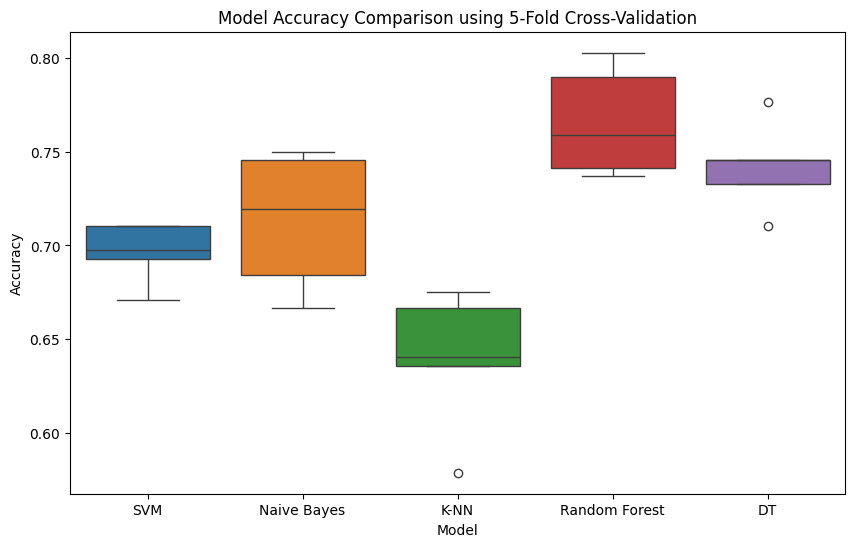

In [16]:
# Assuming 'df' is your DataFrame, with features and the target label column
# Replace 'target_column' with the actual name of your label column
X = data.drop(columns=['science_related'])  # Features
y = data['science_related']  # Labels

# Initialize classifiers
models = {
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-NN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Initialize StratifiedKFold for 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store the accuracy for each model
accuracies = {'SVM': [], 'Naive Bayes': [], 'K-NN': [], 'Random Forest': []}

# Perform 5-fold cross-validation for each model
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    accuracies[model_name] = cv_scores

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame(accuracies)

# Plot the boxplot for accuracy distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=accuracy_df)
plt.title('Model Accuracy Comparison using 5-Fold Cross-Validation')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

# 2. Feature selection

Pour garder uniquement les features les plus pertinentes pour entrainer le modèle : réduit le bruit et réduit la taille des données (donc le coût d'entrainement)

## Filtrage des données par variance

La variance est un bon indicateur de la quantité d'information d'une feature, plus les valeurs varient plus cette feature est pertinente

### Distribution des variances des features

On cherche le "coude" de la distribution, ici les valeurs les moins pertinentes sont en dessous de 0.001

Text(0.5, 1.0, 'Distribution des variance dans les donnés')

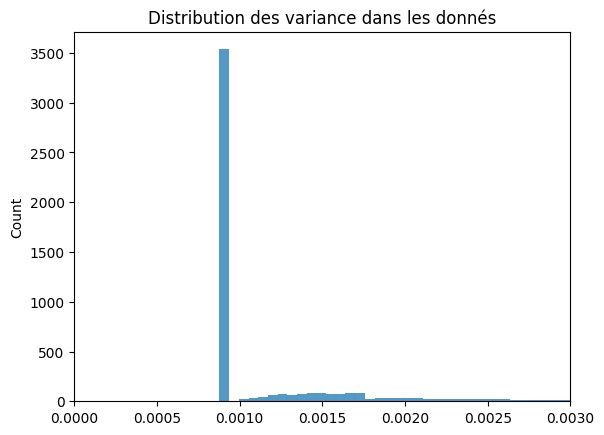

In [17]:
ax = sns.histplot(data=data.var().values)
ax.set_xlim(0, 0.003)
ax.set_title("Distribution des variance dans les donnés")

In [18]:
print(data.shape)
sel = VarianceThreshold(0.0010)
data_var = sel.fit_transform(data.drop(columns=["science_related"]))
data_var = pd.DataFrame(data_var, columns=sel.get_feature_names_out())
data_var["science_related"] = data["science_related"]
print(data_var.shape)
data_var.head()

(1140, 5187)
(1140, 1642)


,aap,ability,able,abortion,about,abuse,academic,academy,accept,accord,...,yet,yoga,york,you,young,your,youth,youtube,yr,science_related
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


## Filtrage par Random Forest

On entraine un modèle de Random Forest, puis on analyse les features les plus déterminante pour le modèle

In [19]:
X = data.drop(columns=['science_related'])
y = data['science_related'] 
print(X.shape)

clf = RandomForestClassifier(random_state=42)
clf = clf.fit(X, y)

model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
print(X_new.shape)

data_rf = pd.DataFrame(X_new)
data_rf["science_related"] = y

(1140, 5186)
(1140, 1058)


/home/elio/Cours/ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## Filtrage par variance + random forest

In [20]:
X = data_var.drop(columns=['science_related'])
y = data_var['science_related'] 
print(X.shape)

clf = RandomForestClassifier(random_state=42)
clf = clf.fit(X, y)

model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
print(X_new.shape)

data_var_rf = pd.DataFrame(X_new)
data_var_rf["science_related"] = y

(1140, 1641)
(1140, 378)


/home/elio/Cours/ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## Séparation des différents datasets

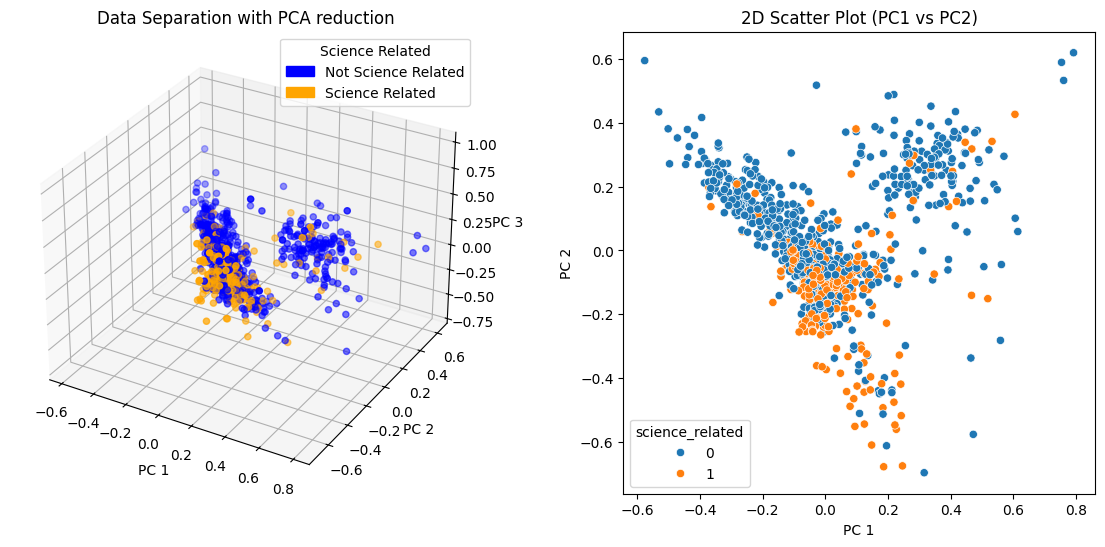

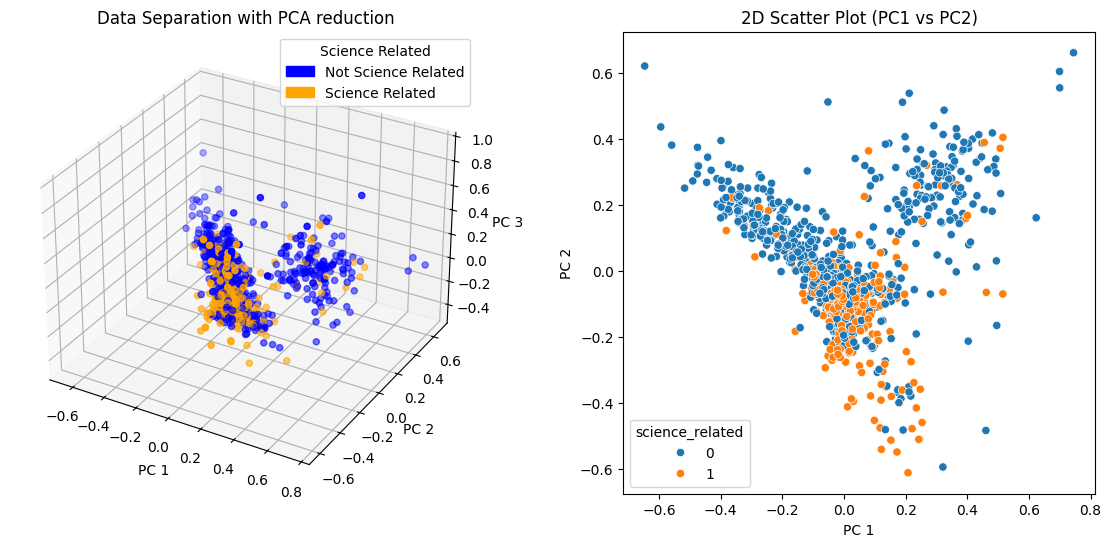

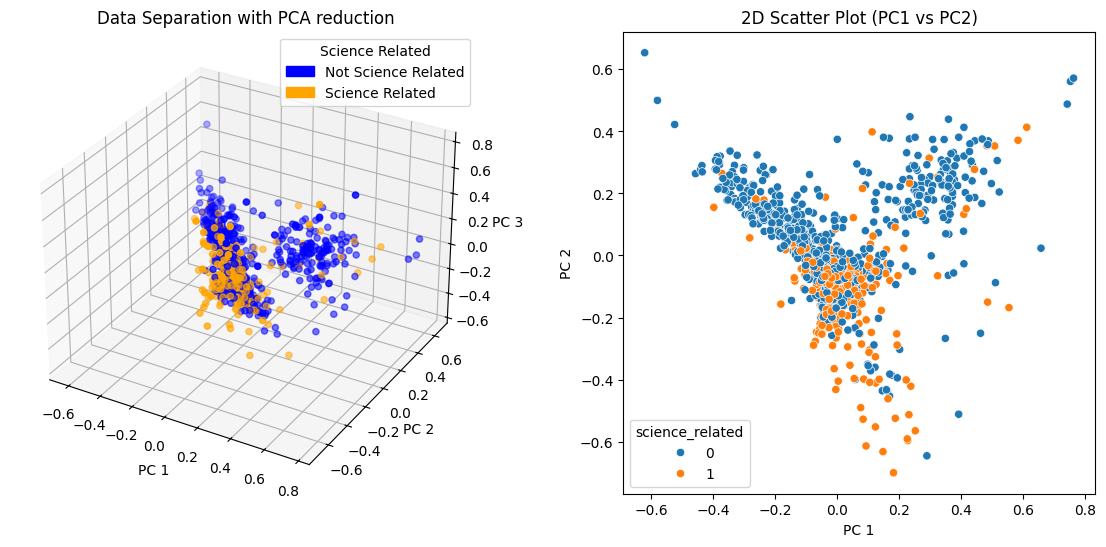

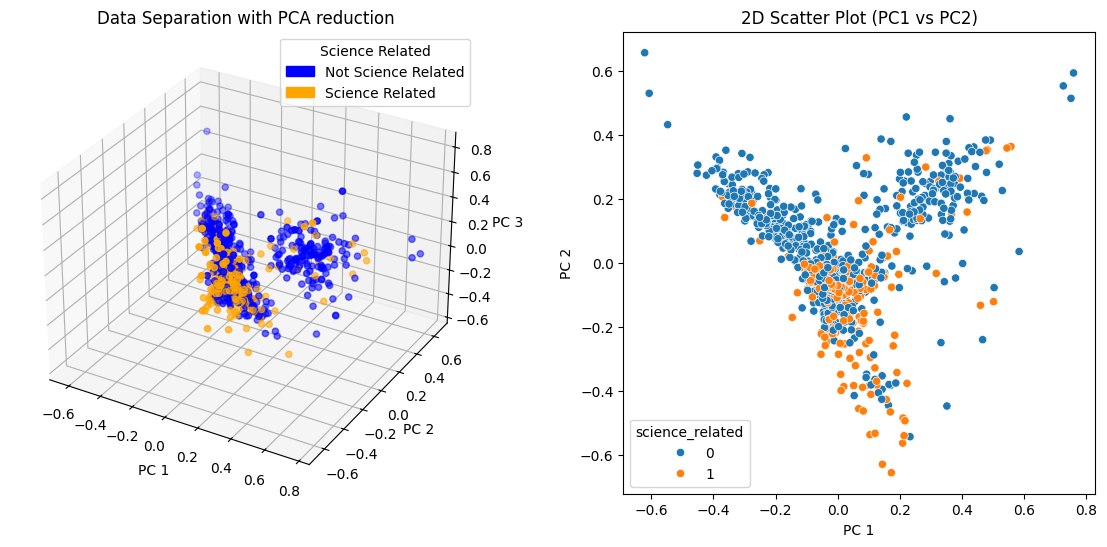

In [21]:
display_separation(data)
display_separation(data_var)
display_separation(data_rf)
display_separation(data_var_rf)

## Précision du modèle selon les sélection de features

Les données filtré par variance donnent des résultats plus robustes.

Cross-validated accuracies for default: [0.80263158 0.74122807 0.78947368 0.73684211 0.75877193]
Mean accuracy for default: 0.7658
Cross-validated accuracies for Variance: [0.82894737 0.77192982 0.78947368 0.79824561 0.78508772]
Mean accuracy for Variance: 0.7947
Cross-validated accuracies for Random Forest: [0.80701754 0.73245614 0.77631579 0.74561404 0.76315789]
Mean accuracy for Random Forest: 0.7649
Cross-validated accuracies for Variance +
Random Forest: [0.78508772 0.76315789 0.77192982 0.75       0.78508772]
Mean accuracy for Variance +
Random Forest: 0.7711


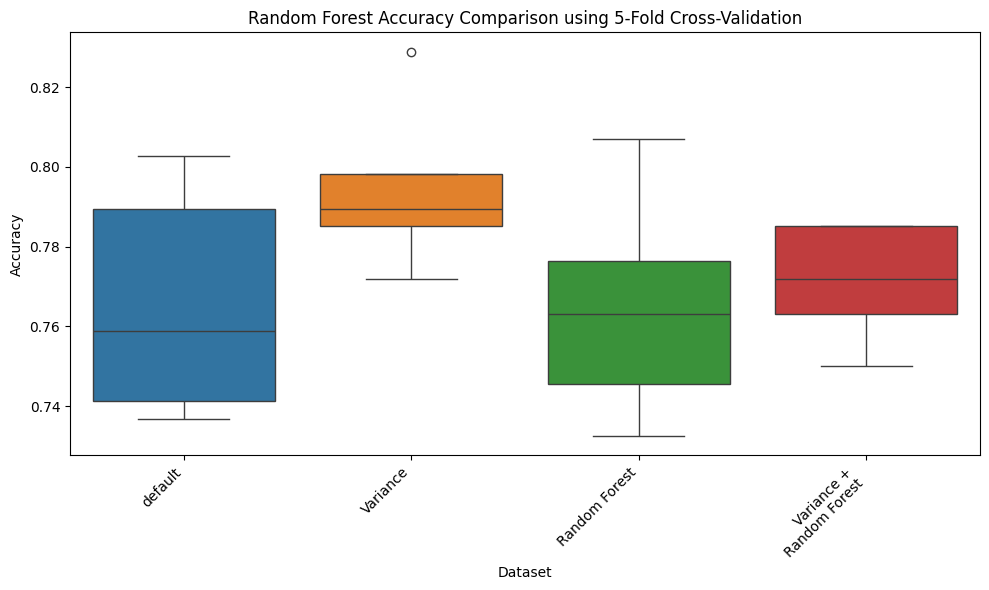

In [22]:
datasets = {
    'default': data,
    'Variance': data_var,
    'Random Forest': data_rf,
    'Variance +\nRandom Forest': data_var_rf
}

accuracies = {}  # To store accuracy for each dataset

# Initialize StratifiedKFold for 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through each dataset
for name, df in datasets.items():
    # Separate features and target (assuming 'target_column' is the column for labels)
    X = df.drop(columns=['science_related'])  # Features
    y = df['science_related']  # Labels

    # Initialize RandomForest model
    rf_model = RandomForestClassifier(random_state=42)

    # Perform 5-fold cross-validation and store the accuracy for each fold
    cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

    # Store the accuracies for each dataset
    accuracies[name] = cv_scores

    print(f"Cross-validated accuracies for {name}: {cv_scores}")
    print(f"Mean accuracy for {name}: {cv_scores.mean():.4f}")

# Create a DataFrame for plotting (to plot a boxplot)
accuracy_df = pd.DataFrame(accuracies)

# Plot the boxplot for accuracy distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=accuracy_df)
plt.title('Random Forest Accuracy Comparison using 5-Fold Cross-Validation')
plt.ylabel('Accuracy')
plt.xlabel('Dataset')
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.tight_layout()  # Adjust layout to fit labels properly
plt.show()


# 3. Recherche d'HyperParamètres

On fait une grid search avec cross validation pour trouver les meilleurs paramètres pour le modèle

In [23]:
X = data_var.drop(columns=['science_related'])  # Features
y = data_var['science_related']  # Labels

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],     # Number of trees
    'max_depth': [None, 10, 20, 30],    # Maximum depth of trees
    'min_samples_split': [2, 5, 10],    # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],      # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2']    # Number of features to consider for a split
}

# Perform GridSearchCV to find the best hyperparameters
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X, y)

# Get the best model and its parameters
best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Print the best parameters
print("Best Hyperparameters:", best_params)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Best Hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


# 4. Évaluation finale

On a un rappel assez faible pour la class 1 (science related), cela est probablement due au déséquilibre dans la quantité de tweet de chaque classe.

In [24]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Assuming you already have your model (e.g., a classifier)
model = RandomForestClassifier(**best_params, random_state=42)

# Perform cross-validation and get predictions
y_pred = cross_val_predict(model, X, y, cv=5)

# Print classification report for cross-validation
print("Classification Report (Overall):")
print(classification_report(y, y_pred))

# Get accuracy for each fold
accuracies = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Accuracy for each fold: {accuracies}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}, Std: {np.std(accuracies):.4f}")

# Calculate precision, recall, and F1-score for the entire cross-validation
precision = precision_score(y, y_pred, average='binary')  # Change 'binary' for multiclass
recall = recall_score(y, y_pred, average='binary')
f1 = f1_score(y, y_pred, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print(f"\nConfusion Matrix:\n{cm}")


Classification Report (Overall):
              precision    recall  f1-score   support

           0       0.79      0.95      0.86       765
           1       0.82      0.50      0.62       375

    accuracy                           0.80      1140
   macro avg       0.81      0.72      0.74      1140
weighted avg       0.80      0.80      0.78      1140

Accuracy for each fold: [0.79824561 0.83333333 0.76315789 0.80701754 0.78947368]
Mean Accuracy: 0.7982, Std: 0.0229
Precision: 0.8194
Recall: 0.4960
F1-Score: 0.6179

Confusion Matrix:
[[724  41]
 [189 186]]


# 5. Balancing data

On sait qu'on a deux fois plus de tweet not science related, que de tweets science related. L'idée est de supprimer quelque tweet de la class not science related et/ou de dupliquer quelque tweets de la class science related.
Ainsi on obtient un jeu de données équilibré.

In [33]:
from sklearn.utils import resample

def get_balanced_df(df):
    class_a = df[df['science_related'] == 0]
    class_b = df[df['science_related'] == 1]
    mean_len = int((len(class_a) + len(class_b)) / 2)

    if len(class_a) >= mean_len:
        class_a_resample = resample(class_a, 
                                replace=False,
                                n_samples=mean_len,  
                                random_state=42)
    else:
        class_a_resample = pd.concat([class_a, resample(class_a, 
                                                        replace=True,
                                                        n_samples=mean_len - len(class_a),  
                                                        random_state=42)])
    if len(class_b) >= mean_len:
        class_b_resample = resample(class_b, 
                                replace=False,
                                n_samples=mean_len,  
                                random_state=42)
    else:
        class_b_resample = pd.concat([class_b, resample(class_b, 
                                                        replace=True,
                                                        n_samples=mean_len - len(class_b),  
                                                        random_state=42)])
    
    balanced_df = pd.concat([class_a_resample, class_b_resample])    
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return balanced_df

def under_sample_only(df):
    class_a = df[df['science_related'] == 0]
    class_b = df[df['science_related'] == 1]
    
    if len(class_a) > len(class_b):
        class_a_resample = resample(class_a, 
                                replace=False,
                                n_samples=len(class_b),  
                                random_state=42)
        class_b_resample = class_b
    else:
        class_b_resample = resample(class_b, 
                                replace=False,
                                n_samples=len(class_a),  
                                random_state=42)
        class_a_resample = class_a

    balanced_df = pd.concat([class_a_resample, class_b_resample])    
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return balanced_df

## Équilibrage par over et undersampling

On sur-échantillone la class moins représenté en dupliquant des données et on sous échantillone la classe plus représenté en supprimant des données.

On peut observer que les performances sont grandement améliorés (presquer 0.1 d'accuracy en plus). Il faut noter cependant qu'il y a un biais pour la classe sur-échantilloné (ou l'on duplique des données) car le même tweet peut apparaitre durant l'entrainement et le test

In [32]:
balanced_data_var = get_balanced_df(data_var)

X = balanced_data_var.drop(columns=['science_related'])  # Features
y = balanced_data_var['science_related']  # Labels

# Assuming you already have your model (e.g., a classifier)
model = RandomForestClassifier(**best_params, random_state=42)

# Perform cross-validation and get predictions
y_pred = cross_val_predict(model, X, y, cv=5)

# Print classification report for cross-validation
print("Classification Report (Overall):")
print(classification_report(y, y_pred))

# Get accuracy for each fold
accuracies = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Accuracy for each fold: {accuracies}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}, Std: {np.std(accuracies):.4f}")

# Calculate precision, recall, and F1-score for the entire cross-validation
precision = precision_score(y, y_pred, average='binary')  # Change 'binary' for multiclass
recall = recall_score(y, y_pred, average='binary')
f1 = f1_score(y, y_pred, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

Classification Report (Overall):
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       570
           1       0.84      0.89      0.86       570

    accuracy                           0.86      1140
   macro avg       0.86      0.86      0.86      1140
weighted avg       0.86      0.86      0.86      1140

Accuracy for each fold: [0.85964912 0.84649123 0.86403509 0.85526316 0.86842105]
Mean Accuracy: 0.8588, Std: 0.0075
Precision: 0.8391
Recall: 0.8877
F1-Score: 0.8627

Confusion Matrix:
[[473  97]
 [ 64 506]]


## Équilibrage avec under-sampling uniquement

On sous échantillone la classe sur représenté. Comme on ne duplique pas de données on évite les biais.

On a certe de moins bon résultats pour la classe 0 mais on a de meilleurs résultats pour la classe 1 donc le modèle est mieux équilibré I suppose.

In [34]:
balanced_data_var = under_sample_only(data_var)

X = balanced_data_var.drop(columns=['science_related'])  # Features
y = balanced_data_var['science_related']  # Labels

# Assuming you already have your model (e.g., a classifier)
model = RandomForestClassifier(**best_params, random_state=42)

# Perform cross-validation and get predictions
y_pred = cross_val_predict(model, X, y, cv=5)

# Print classification report for cross-validation
print("Classification Report (Overall):")
print(classification_report(y, y_pred))

# Get accuracy for each fold
accuracies = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Accuracy for each fold: {accuracies}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}, Std: {np.std(accuracies):.4f}")

# Calculate precision, recall, and F1-score for the entire cross-validation
precision = precision_score(y, y_pred, average='binary')  # Change 'binary' for multiclass
recall = recall_score(y, y_pred, average='binary')
f1 = f1_score(y, y_pred, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

Classification Report (Overall):
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       375
           1       0.76      0.82      0.79       375

    accuracy                           0.78       750
   macro avg       0.78      0.78      0.78       750
weighted avg       0.78      0.78      0.78       750

Accuracy for each fold: [0.74666667 0.78       0.77333333 0.79333333 0.80666667]
Mean Accuracy: 0.7800, Std: 0.0202
Precision: 0.7574
Recall: 0.8240
F1-Score: 0.7893

Confusion Matrix:
[[276  99]
 [ 66 309]]
